SUPPORT VECTOR MACHINE

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Scikit-learn for SVM and model evaluation.
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# For reproducibility
import random
random.seed(42)
np.random.seed(42)

tumors = pd.read_excel("brain_tumor_dataset-1.xlsx")
tumors.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,37,70,Male,Benign,8.247936,Temporal,Astrocytoma,IV,Headache,Headache,Headache,No,No,No,64.476484,2.025792,Yes,Negative,Yes
1,266,28,Male,Benign,2.173214,Parietal,Astrocytoma,II,Headache,Headache,Headache,No,Yes,No,97.286216,1.207089,No,Positive,No
2,388,42,Female,Benign,5.419235,Parietal,Glioblastoma,II,Headache,Headache,Headache,No,Yes,Yes,89.438163,1.767080,No,Negative,Yes
3,501,31,Female,Benign,7.541449,Parietal,Medulloblastoma,II,Headache,Headache,Headache,Yes,No,No,95.183054,2.919758,No,Positive,No
4,586,55,Female,Benign,3.192184,Parietal,Glioblastoma,IV,Headache,Headache,Headache,No,Yes,No,102.752962,1.111476,Yes,Negative,No


In [3]:
# dataset info and summary statistics
print(tumors.info())
print(tumors.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  str    
 3   Tumor_Type           20000 non-null  str    
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  str    
 6   Histology            20000 non-null  str    
 7   Stage                20000 non-null  str    
 8   Symptom_1            20000 non-null  str    
 9   Symptom_2            20000 non-null  str    
 10  Symptom_3            20000 non-null  str    
 11  Radiation_Treatment  20000 non-null  str    
 12  Surgery_Performed    20000 non-null  str    
 13  Chemotherapy         20000 non-null  str    
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null  float64
 1

Data cleaning and transformation

In [4]:
tumors.columns

Index(['Patient_ID', 'Age', 'Gender', 'Tumor_Type', 'Tumor_Size', 'Location',
       'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy',
       'Survival_Rate', 'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
       'Follow_Up_Required'],
      dtype='str')

In [5]:
categorical_columns = ['Gender', 'Tumor_Type', 'Location', 'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']

numerical_columns = ['Patient_ID','Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']

for column in numerical_columns:
    tumors[column] = tumors[column].fillna(tumors[column].mean())

for column in categorical_columns:
    tumors[column] = tumors[column].fillna(tumors[column].mode()[0])

In [6]:
#missing values
print(tumors.isnull().sum())

Patient_ID             0
Age                    0
Gender                 0
Tumor_Type             0
Tumor_Size             0
Location               0
Histology              0
Stage                  0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
Survival_Rate          0
Tumor_Growth_Rate      0
Family_History         0
MRI_Result             0
Follow_Up_Required     0
dtype: int64


In [7]:
tumors_categorical = tumors[categorical_columns]
tumors_numerical = tumors[numerical_columns]

tumors_cat_encoded = pd.get_dummies(tumors_categorical, columns=['Gender', 'Tumor_Type', 'Location', 'Histology', 'Stage', 'Symptom_1', 'Symptom_2', 'Symptom_3','Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy','Family_History', 'Follow_Up_Required'], drop_first=True)

scaler = StandardScaler()

tumors_num_scaled = pd.DataFrame(scaler.fit_transform(tumors_numerical), columns=numerical_columns)

tumors_encoded = pd.concat([tumors_num_scaled, tumors_cat_encoded], axis=1)

#Transform boolean columns into integer columns
tumors_encoded['MRI_Result'] = tumors_encoded['MRI_Result'].map({'Negative': 0, 'Positive': 1})
tumors_encoded['Gender_Male'] = tumors_encoded['Gender_Male'].astype(int)
tumors_encoded['Tumor_Type_Malignant'] = tumors_encoded['Tumor_Type_Malignant'].astype(int)
tumors_encoded['Location_Occipital'] = tumors_encoded['Location_Occipital'].astype(int)
tumors_encoded['Location_Parietal'] = tumors_encoded['Location_Parietal'].astype(int)
tumors_encoded['Location_Temporal'] = tumors_encoded['Location_Temporal'].astype(int)
tumors_encoded['Histology_Glioblastoma'] = tumors_encoded['Histology_Glioblastoma'].astype(int)
tumors_encoded['Histology_Medulloblastoma'] = tumors_encoded['Histology_Medulloblastoma'].astype(int)
tumors_encoded['Histology_Meningioma'] = tumors_encoded['Histology_Meningioma'].astype(int)
tumors_encoded['Stage_II'] = tumors_encoded['Stage_II'].astype(int)
tumors_encoded['Stage_III'] = tumors_encoded['Stage_III'].astype(int)
tumors_encoded['Stage_IV'] = tumors_encoded['Stage_IV'].astype(int)
tumors_encoded['Symptom_1_Nausea'] = tumors_encoded['Symptom_1_Nausea'].astype(int)
tumors_encoded['Symptom_1_Seizures'] = tumors_encoded['Symptom_1_Seizures'].astype(int)
tumors_encoded['Symptom_1_Vision Issues'] = tumors_encoded['Symptom_1_Vision Issues'].astype(int)
tumors_encoded['Symptom_2_Nausea'] = tumors_encoded['Symptom_2_Nausea'].astype(int)
tumors_encoded['Symptom_2_Seizures'] = tumors_encoded['Symptom_2_Seizures'].astype(int)
tumors_encoded['Symptom_2_Vision Issues'] = tumors_encoded['Symptom_2_Vision Issues'].astype(int)
tumors_encoded['Symptom_3_Nausea'] = tumors_encoded['Symptom_3_Nausea'].astype(int)
tumors_encoded['Symptom_3_Seizures'] = tumors_encoded['Symptom_3_Seizures'].astype(int)
tumors_encoded['Symptom_3_Vision Issues'] = tumors_encoded['Symptom_3_Vision Issues'].astype(int)
tumors_encoded['Radiation_Treatment_Yes'] = tumors_encoded['Radiation_Treatment_Yes'].astype(int)
tumors_encoded['Surgery_Performed_Yes'] = tumors_encoded['Surgery_Performed_Yes'].astype(int)
tumors_encoded['Chemotherapy_Yes'] = tumors_encoded['Chemotherapy_Yes'].astype(int)
tumors_encoded['Family_History_Yes'] = tumors_encoded['Family_History_Yes'].astype(int)
tumors_encoded['Follow_Up_Required_Yes'] = tumors_encoded['Follow_Up_Required_Yes'].astype(int)

tumors_encoded.head()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate,MRI_Result,Gender_Male,Tumor_Type_Malignant,Location_Occipital,Location_Parietal,...,Symptom_2_Seizures,Symptom_2_Vision Issues,Symptom_3_Nausea,Symptom_3_Seizures,Symptom_3_Vision Issues,Radiation_Treatment_Yes,Surgery_Performed_Yes,Chemotherapy_Yes,Family_History_Yes,Follow_Up_Required_Yes
0,-1.725729,1.315893,1.010166,-0.784743,0.571897,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,-1.686065,-1.158481,-1.019161,1.045839,-0.407444,1,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,-1.664934,-0.333690,0.065208,0.607965,0.262422,0,0,0,0,1,...,0,0,0,0,0,0,1,1,0,1
3,-1.645362,-0.981740,0.774157,0.928495,1.641267,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,-1.630639,0.432188,-0.678763,1.350849,-0.521817,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


In [8]:
print(tumors_encoded.columns)

Index(['Patient_ID', 'Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate',
       'MRI_Result', 'Gender_Male', 'Tumor_Type_Malignant',
       'Location_Occipital', 'Location_Parietal', 'Location_Temporal',
       'Histology_Glioblastoma', 'Histology_Medulloblastoma',
       'Histology_Meningioma', 'Stage_II', 'Stage_III', 'Stage_IV',
       'Symptom_1_Nausea', 'Symptom_1_Seizures', 'Symptom_1_Vision Issues',
       'Symptom_2_Nausea', 'Symptom_2_Seizures', 'Symptom_2_Vision Issues',
       'Symptom_3_Nausea', 'Symptom_3_Seizures', 'Symptom_3_Vision Issues',
       'Radiation_Treatment_Yes', 'Surgery_Performed_Yes', 'Chemotherapy_Yes',
       'Family_History_Yes', 'Follow_Up_Required_Yes'],
      dtype='str')


In [9]:
y = tumors_encoded['Tumor_Type_Malignant']
X = tumors_encoded.drop(columns=['Tumor_Type_Malignant', 'Patient_ID'])

In [10]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='str')


 Splitting the Data into Training and Testing Sets

In [11]:
# Splitting data: 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3
                                                    , random_state=42, stratify=y)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 14000
Test samples: 6000


In [12]:
# Initialize and train an SVM classifier with the RBF kernel
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_clf.predict(X_test)
print("Accuracy (default SVM):", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy (default SVM): 0.8098333333333333
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2991
           1       0.82      0.80      0.81      3009

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



Hyperparameters and Model Nuances

In [13]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'degree': [2, 3]
}
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)


print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score: {:.3f}".format(grid_search.best_score_))
print("Accuracy (tuned SVM):", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Best parameters from GridSearchCV: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.806
Accuracy (tuned SVM): 0.8098333333333333
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2991
           1       0.82      0.80      0.81      3009

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



RANDOM FOREST

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
# Load data

df = pd.read_excel("brain_tumor_dataset-1.xlsx")

In [ ]:
# 1) the feature engineering. Here, we drop ID because its not a medical fact, just a label

df_ml = df.drop(columns=['Patient_ID'])

# 2) Do a binary mapping. We will change malignant/benign into numbers (1 and 0)

df_ml['Tumor_Type'] = df_ml['Tumor_Type'].map({'Malignant': 1, 'Benign': 0})
df_ml['Gender'] = df_ml['Gender'].map({'Male': 1, 'Female': 0})
df_ml['MRI_Result'] = df_ml['MRI_Result'].map({'Positive': 1, 'Negative': 0})

binary_cols = ['Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'Follow_Up_Required']
for col in binary_cols:
    df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

# 3) Do a ordinal mapping. Give "stage" numerical ranking

df_ml['Stage'] = df_ml['Stage'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

# 4) Do a symptom logic. We will search keywords in the 3 sympton columns

unique_symptoms = ['Headache', 'Nausea', 'Seizures', 'Vision Issues']
for sym in unique_symptoms:
    df_ml[f'Has_{sym}'] = (
        (df_ml['Symptom_1'] == sym) |
        (df_ml['Symptom_2'] == sym) |
        (df_ml['Symptom_3'] == sym)
    ).astype(int)

# 5. Eliminate old text columns and make sure to apply "One-Hot Encoding" for the rest.

df_m1 = df_ml.drop(columns=['Symptom_1', 'Symptom_2', 'Symptom_3'])
df_ml = pd.get_dummies(df_m1, columns=['Location', 'Histology'], drop_first=True)

# We do data splitting

#The "X" represents things like symptoms, age and size
X = df_ml.drop(columns=['Tumor_Type'])

#The "Y" represents answers like Malignant and Benign
y = df_ml['Tumor_Type']
#We do split in 80% for training and then 20% for testing if the machine learned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#We find the best forest (model tunning), we will tell the computer to try different parameters to find the best setting

param_grid = {
    'n_estimators': [100, 300],    # In here, we want to define the number of trees
    'max_depth': [10, 20, None],    # In here, we want to define How deep should trees be
    'min_samples_leaf': [1, 4]      # In here, we want to define the Minimum patients needed to make a decision.
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

#We define the winner model

best_model = grid_search.best_estimator_

#The final results

y_pred = best_model.predict(X_test)
print(f"Winning Parameters: {grid_search.best_params_}")
print("\n--- Competition Report ---")
print(classification_report(y_test, y_pred))

Winning Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}

--- Competition Report ---
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1994
           1       0.82      0.81      0.82      2006

    accuracy                           0.82      4000
   macro avg       0.82      0.82      0.82      4000
weighted avg       0.82      0.82      0.82      4000



Decision trees

In [41]:
# Using as base the previous steps, we will skip some parts as they have been already done.

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel("brain_tumor_dataset-1.xlsx")

In [ ]:
df = df.drop(columns=["Patient_ID"])

df["Tumor_Type"] = df["Tumor_Type"].map({"Benign": 0, "Malignant": 1})

df = pd.get_dummies(df, drop_first=True)

In [46]:
X = df.drop(columns=["Tumor_Type"])
y = df["Tumor_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
# Hyperparameters tuning
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=10),  
    param_grid,
    cv=5,
    scoring='f1', 
    n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score: {:.3f}".format(grid_search.best_score_))

Best parameters from GridSearchCV: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validation score: 0.800


Accuracy (tuned): 0.80375

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1994
           1       0.80      0.81      0.81      2006

    accuracy                           0.80      4000
   macro avg       0.80      0.80      0.80      4000
weighted avg       0.80      0.80      0.80      4000



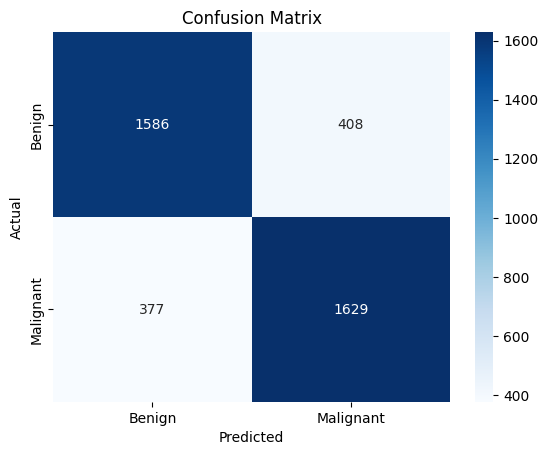

In [65]:
# GrisearchCV
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)

print("Accuracy (tuned):", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

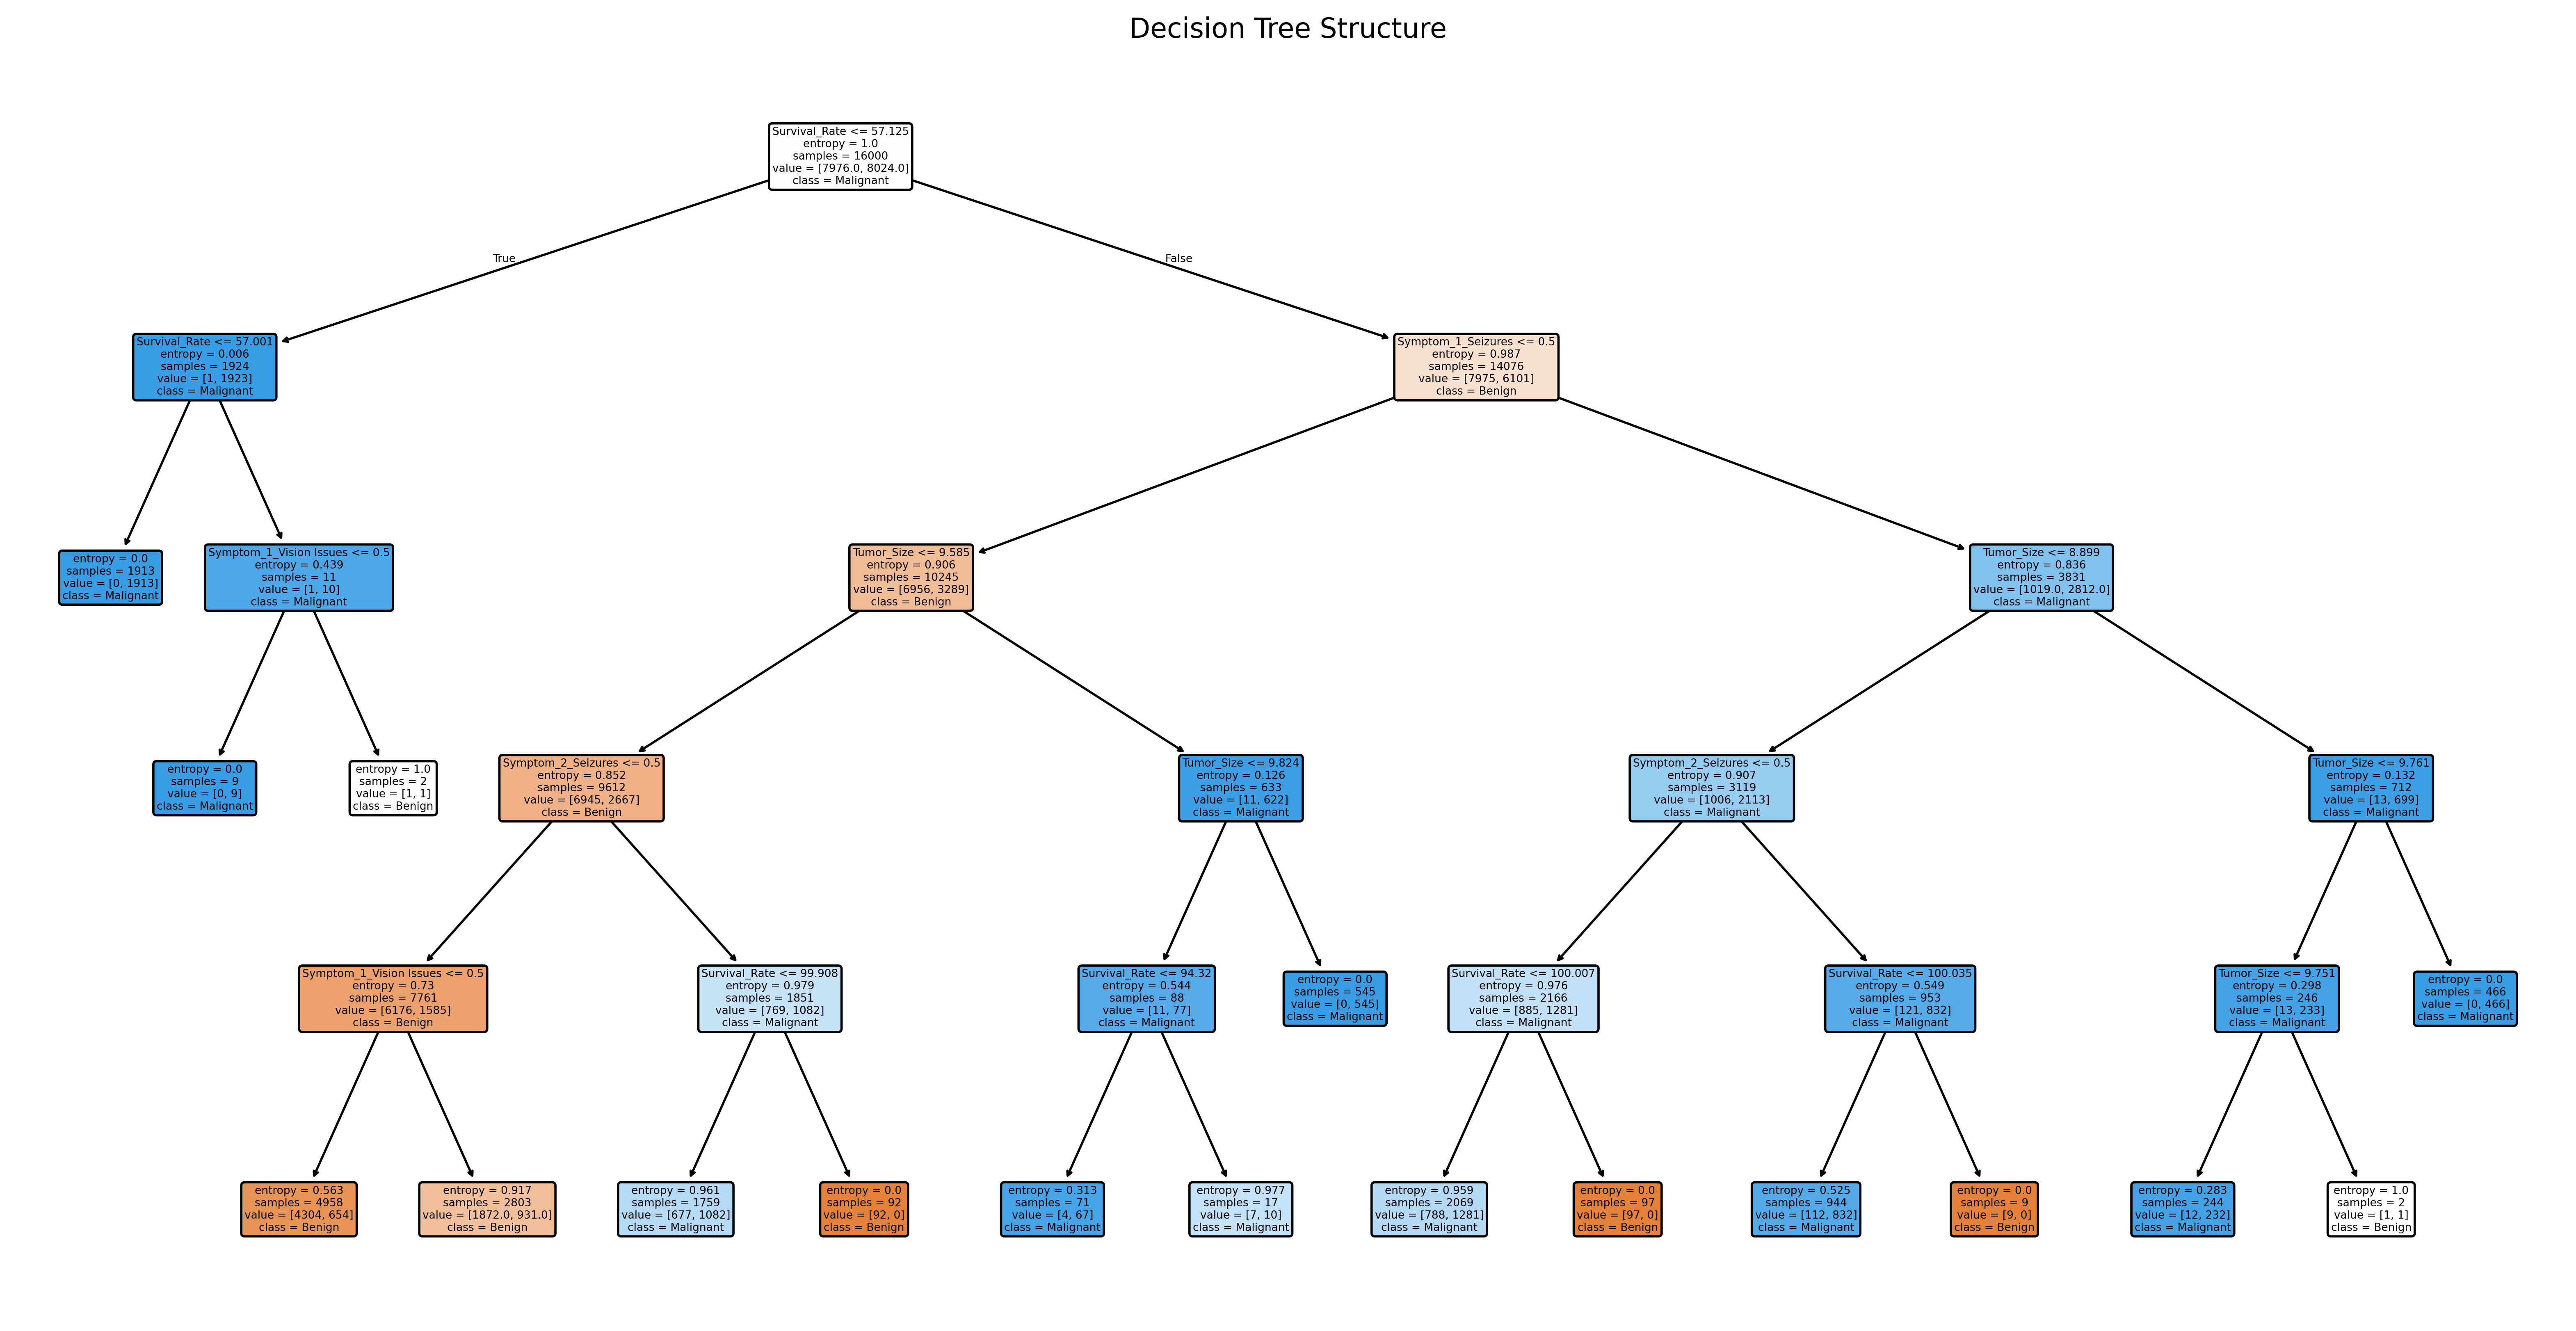

In [63]:
plt.figure(figsize=(20,10), dpi=400)

plot_tree(best_dt, feature_names=X.columns, class_names=["Benign", "Malignant"], filled=True, rounded=True)

plt.title("Decision Tree Structure")
plt.show()

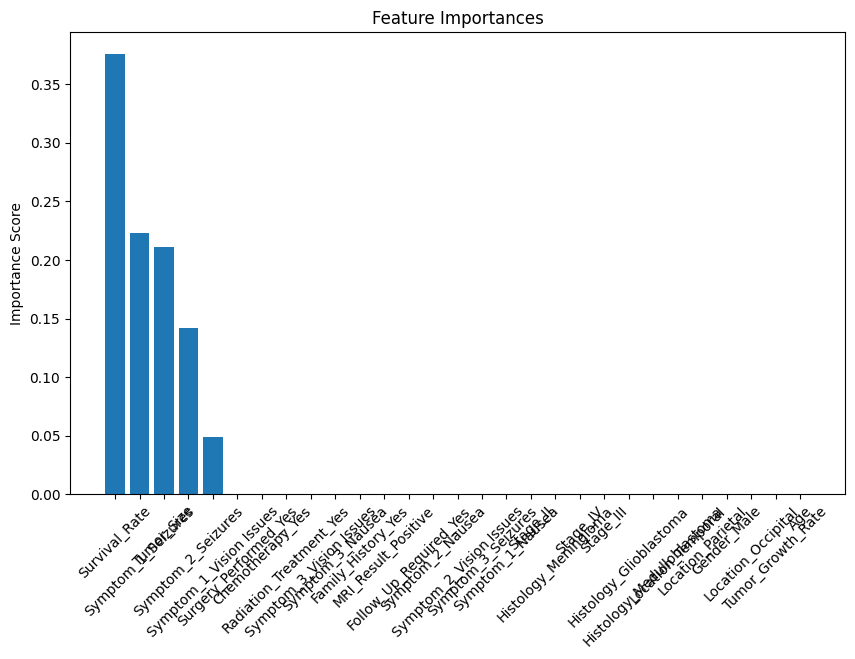

In [64]:
# Plot feature importances
importances = best_dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.ylabel("Importance Score")
plt.show()